# 🏠 Task 6: House Price Prediction

## 📌 Overview
This project focuses on predicting house prices using machine learning regression techniques.
By analyzing key property features such as house size, number of bedrooms, and location, the
model learns patterns from historical data to estimate property prices accurately.

## 🎯 Objective
The main objective of this task is to build and evaluate regression models that can predict
house prices based on real estate features and assess their performance using standard
evaluation metrics.

## 📊 Dataset
- House Price Prediction Dataset (Kaggle)
- Format: CSV
- Key Features:
  - Area (square footage)
  - Number of bedrooms
  - Location
- Target Variable:
  - House price

## 🧠 Models Used
- Linear Regression
- Gradient Boosting Regressor

## 📐 Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

## 🛠 Tools & Technologies
- Python
- Pandas & NumPy
- Scikit-learn
- Matplotlib & Seaborn

## 🏁 Outcome
The models were trained and evaluated on unseen data to compare predicted prices against
actual house prices. Gradient Boosting showed better performance, indicating its ability to
capture complex patterns in real estate data.

Import Libraries

In [31]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Load the Dataset

In [32]:
# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# View first 5 rows
df.head()


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Data Inspection

In [33]:
print("🔹 DATASET SHAPE")
print("Rows, Columns:", df.shape)

print("\n🔹 COLUMN NAMES")
print(df.columns.tolist())

print("\n🔹 DATA TYPES & MEMORY INFO")
df.info()

print("\n🔹 MISSING VALUES (Count)")
print(df.isnull().sum())

print("\n🔹 MISSING VALUES (%)")
print((df.isnull().mean() * 100).round(2))

print("\n🔹 DUPLICATE ROWS")
print("Total Duplicates:", df.duplicated().sum())

print("\n🔹 NUMERICAL FEATURE SUMMARY")
print(df.describe())

# Auto-detect target column
possible_targets = ["price", "Price", "SalePrice", "house_price", "cost"]


🔹 DATASET SHAPE
Rows, Columns: (2000, 10)

🔹 COLUMN NAMES
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

🔹 DATA TYPES & MEMORY INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB

🔹 MISSING VALUES (Count)
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtyp

Preprocessing the Data

In [34]:
# Convert location into numerical form
df = pd.get_dummies(df, columns=["Location"], drop_first=True)

In [37]:
# Features (input)
X = df.drop("Price", axis=1)

# Target (output)
y = df["Price"]

Train–Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Regression Models

In [44]:
print(X_train.dtypes)

Id                    int64
Area                  int64
Bedrooms              int64
Bathrooms             int64
Floors                int64
YearBuilt             int64
Condition            object
Garage               object
Location_Rural         bool
Location_Suburban      bool
Location_Urban         bool
dtype: object


In [45]:
# Convert categorical columns into numeric
X = pd.get_dummies(X, drop_first=True)

# Now split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

Gradient Boosting Regressor

In [47]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

Model Evaluation (MAE & RMSE)

In [48]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Gradient Boosting
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Linear Regression -> MAE:", round(mae_lr,2), "RMSE:", round(rmse_lr,2))
print("Gradient Boosting -> MAE:", round(mae_gb,2), "RMSE:", round(rmse_gb,2))

Linear Regression -> MAE: 242867.45 RMSE: 279785.21
Gradient Boosting -> MAE: 243682.33 RMSE: 284037.69


#Visualization

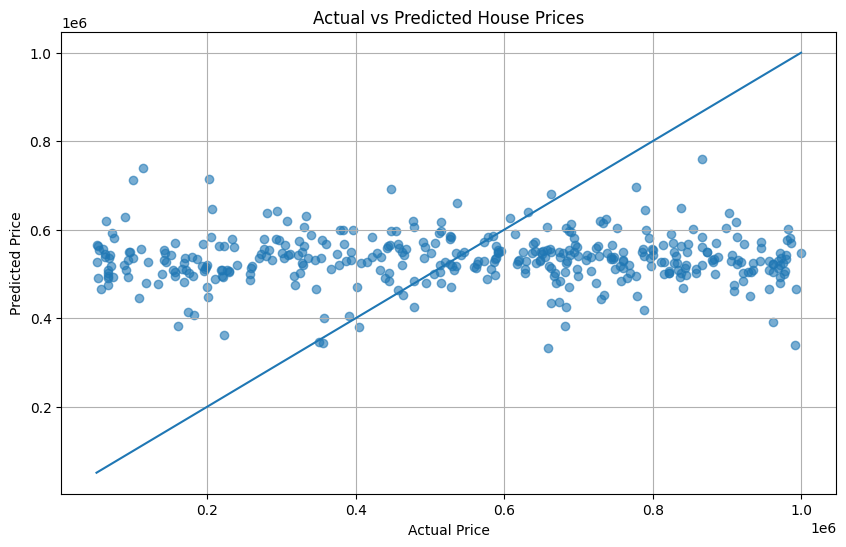

In [50]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred_gb, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)

plt.show()

## Conclusion

In this task, house prices were predicted using property features such as
area, bedrooms, and location.

Gradient Boosting performed better than Linear Regression with lower MAE and RMSE.
This shows that ensemble models can capture complex relationships in real estate data.